# Object Detection — Fine-Tuning Faster R-CNN on Penn-Fudan Pedestrians

**Notebook 06 · Localisation** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

Classification answers *what*. Detection answers *what and where*, for a **variable number** of
objects. That last property changes everything: the output is no longer a fixed-size logit vector but
a list whose length depends on the image content, and almost every awkward part of a detection
pipeline — the loss, the batching, the export story — follows from it.

This notebook fine-tunes a COCO-pretrained **Faster R-CNN R50-FPN v2** on Penn-Fudan (170 images,
345 annotated pedestrians), evaluates with proper **mAP**, and is honest about the parts of
deployment that are genuinely harder here than for a classifier.

## The two-stage architecture

```
     image (3, H, W)   -- any size; the model resizes internally
          │
   ┌──────▼───────┐
   │  ResNet-50   │  backbone
   └──────┬───────┘
          │  C2 C3 C4 C5   (multi-scale feature maps)
   ┌──────▼───────┐
   │     FPN      │  top-down path + lateral connections: every level gets
   └──────┬───────┘  semantic depth AND spatial resolution
          │  P2 P3 P4 P5 P6
   ┌──────▼───────────────────┐
   │  RPN  (stage 1)          │  slides anchors over every level, predicts
   │  objectness + box deltas │  "is there SOMETHING here?" -> ~1000 proposals
   └──────┬───────────────────┘
          │
   ┌──────▼───────────────────┐
   │  RoIAlign -> box head    │  (stage 2)  per-proposal: which class, and a
   │  classifier + regressor  │  refined box
   └──────┬───────────────────┘
          │
        NMS  -> final detections (variable count!)
```

**Why two stages.** The RPN solves a class-agnostic, easy problem (object vs background) over a huge
number of anchors. The second stage then solves the hard problem (which class, exact box) over ~1000
survivors instead of ~200,000 anchors. One-stage detectors like YOLO or RetinaNet skip the RPN and
trade a little accuracy for a lot of speed.

**Why FPN.** In a plain CNN, deep features are semantically rich but spatially coarse, and shallow
features are the reverse. A small pedestrian is nearly invisible at C5. FPN builds a top-down pathway
that merges deep semantics back into high-resolution maps, so small objects are detected on
high-resolution levels that still know what an object is.

## The mathematics

**IoU** — the currency of detection. Every assignment, every NMS decision, every metric:

$$\text{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

**Anchor assignment.** An anchor is positive if IoU with some ground-truth box $\geq 0.7$, negative
if $< 0.3$, and *ignored* in between — the ambiguous band contributes no gradient rather than a noisy
one.

**Box regression** is parameterised as a *relative* transform, not absolute coordinates, so the
target is scale-invariant:

$$t_x = \frac{x - x_a}{w_a},\quad t_y = \frac{y - y_a}{h_a},\quad
t_w = \log\frac{w}{w_a},\quad t_h = \log\frac{h}{h_a}$$

The $\log$ on width and height matters: it makes a factor-of-2 error cost the same whether the object
is 20 px or 200 px wide.

**The multi-task loss** — four terms, two per stage:

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{obj}} + \mathcal{L}_{\text{rpn-box}}}_{\text{stage 1}}
+ \underbrace{\mathcal{L}_{\text{cls}} + \mathcal{L}_{\text{box}}}_{\text{stage 2}}$$

Box terms use **smooth L1** (Huber), quadratic near zero and linear beyond — L2's gradient grows
without bound on outliers, and one badly-annotated box should not dominate an update:

$$\text{smooth}_{L_1}(x) = \begin{cases} 0.5x^2/\beta & |x| < \beta \\ |x| - 0.5\beta & \text{otherwise}\end{cases}$$

**mAP** — average precision is the area under the precision-recall curve, averaged over classes.
COCO-style mAP averages again over IoU thresholds $0.50{:}0.05{:}0.95$, which is why it is always
much lower than the mAP@0.50 that older papers report. A model at 0.75 mAP@0.50 might be at 0.45
COCO mAP; they are different numbers and quoting the wrong one is a common way to sound better than
you are.

## Provenance

Replaces `nw Build and deploy a custom object detection model with TensorFlow Lite (Android).ipynb`,
which contained nothing but `pip install` cells for **`tflite-model-maker`** — a library deprecated
and unmaintained, pinned to TensorFlow 2.11 and protobuf 3.20, and no longer installable on any
current Python. Its stated goal (train a custom detector, export for on-device inference) is
delivered here on a maintained stack.

---

# 2. Setup & Reproducibility

Same preamble as the rest of the folder, plus the dataset download. Penn-Fudan is a 53 MB zip that
`torchvision` does not wrap, so it is fetched and unpacked here — idempotently, so re-running the
cell is free.

In [1]:
%pip install onnxruntime onnxscript albumentations torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.3 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import os
import platform
import random
import tempfile
import time
import urllib.request
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Final

import albumentations as A
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset, Subset
from torchmetrics.detection import MeanAveragePrecision
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_V2_Weights,
    fasterrcnn_resnet50_fpn_v2,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)

SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
_TMP: Final[Path] = Path(tempfile.gettempdir())
DATA_ROOT: Final[Path] = _TMP / "vision-data"
ARTIFACT_DIR: Final[Path] = _TMP / "vision-artifacts" / "06_object_detection"
DATASET_URL: Final[str] = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
DATASET_DIR: Final[Path] = DATA_ROOT / "PennFudanPed"

# Background is class 0 by torchvision convention; pedestrian is class 1.
NUM_CLASSES: Final[int] = 2
CLASS_NAMES: Final[tuple[str, ...]] = ("__background__", "pedestrian")
TEST_SPLIT_SIZE: Final[int] = 50

# Fast defaults for reference use. Production: raise toward the full 120 / 50
# train/test split (or None / None to skip truncation entirely).
TRAIN_SUBSET_SIZE: Final[int | None] = 16
TEST_SUBSET_SIZE: Final[int | None] = 8

# Set DETERMINISTIC=0 to let cuDNN autotune. On a CUDA GPU this speeds up every
# convolution substantially; it costs exact run-to-run reproducibility.
DETERMINISTIC: Final[bool] = os.getenv("DETERMINISTIC", "1") == "1"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = DETERMINISTIC) -> None:
    """Seed every RNG that can influence a training run.

    Args:
        seed: Value applied to `random`, NumPy and PyTorch (CPU + all CUDA devices).
        deterministic: Force cuDNN's deterministic algorithm set and disable its
            autotuner. Both affect **convolutions only**, so on a CUDA GPU this is the
            first thing to check when a conv-heavy model seems disproportionately slow.
            Defaults to the `DETERMINISTIC` environment variable (on unless set to 0).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, where gradient underflow is a real risk.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        return cls(device, False, torch.float32, needs_grad_scaler=False)


def download_penn_fudan(root: Path = DATA_ROOT) -> Path:
    """Download and unpack Penn-Fudan if it is not already present.

    Args:
        root: Directory to unpack into.

    Returns:
        Path to the unpacked `PennFudanPed` directory.
    """
    target = root / "PennFudanPed"
    if (target / "PNGImages").is_dir():
        return target

    archive = root / "PennFudanPed.zip"
    print(f"downloading {DATASET_URL} ...")
    urllib.request.urlretrieve(DATASET_URL, archive)
    with zipfile.ZipFile(archive) as handle:
        handle.extractall(root)
    archive.unlink(missing_ok=True)
    print(f"unpacked to {target}")
    return target


seed_everything()
DEVICE: Final[torch.device] = get_device()
RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)
dataset_dir = download_penn_fudan()

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("cpu count", str(os.cpu_count())),
    ("seed", str(SEED)),
    ("deterministic", f"{DETERMINISTIC}" + ("  <- slows convolutions" if DETERMINISTIC else "")),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")
print(f"\ndataset: {dataset_dir}  "
      f"({len(list((dataset_dir / 'PNGImages').glob('*.png')))} images)")

---

# 3. Data Pipeline

Penn-Fudan ships **instance masks**, not boxes. Each mask is a single-channel PNG where pixel value
$k$ marks instance $k$ and 0 is background, so boxes are derived by taking each instance's extent.
Deriving boxes from masks rather than trusting a separate annotation file removes a whole class of
box/mask desynchronisation bugs.

### This is where Albumentations earns its place in this repository

Notebook 03 justified Albumentations on the promise that it transforms **images and boxes together**.
This is that notebook. `A.BboxParams` makes the augmentation pipeline box-aware:

- `format="pascal_voc"` — boxes as absolute `[x_min, y_min, x_max, y_max]`, matching what torchvision
  detection models expect. Getting this wrong (COCO's `[x, y, w, h]`, or YOLO's normalised
  centre-form) is the single most common detection bug, and it fails *silently* — the model trains,
  the loss decreases, the boxes are simply wrong.
- `min_visibility=0.3` — after a crop, drop any box with less than 30 % of its original area left.
  Without this, a horizontal flip plus crop can leave a 2-pixel sliver of a pedestrian still labelled
  as a full pedestrian, teaching the model that slivers are people.
- `label_fields=["labels"]` — keeps the label array in lockstep when boxes are dropped.

### A degenerate-box guard

Albumentations can produce zero-area boxes at image borders after an affine transform. torchvision's
loss produces `NaN` on a box with `x_max <= x_min`, and it does so several minutes into training with
no useful traceback. The dataset filters them explicitly — cheap insurance against an expensive
debugging session.

In [3]:
def build_transforms(train: bool) -> A.Compose:
    """Compose a box-aware augmentation pipeline.

    Args:
        train: If True, apply stochastic augmentation. Evaluation is deterministic.

    Returns:
        An Albumentations pipeline. Call it as `t(image=..., bboxes=..., labels=...)`;
        it returns all three, kept consistent with each other.
    """
    box_params = A.BboxParams(
        format="pascal_voc",     # [x_min, y_min, x_max, y_max] absolute -- torchvision's format
        label_fields=["labels"],
        min_visibility=0.3,      # drop boxes mostly cropped away rather than mislabelling slivers
        min_area=16,
    )

    if not train:
        # No resize: Faster R-CNN has its own GeneralizedRCNNTransform that resizes and
        # normalises internally. Doing it twice would be wrong.
        return A.Compose([ToTensorV2()], bbox_params=box_params)

    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.Affine(scale=(0.85, 1.15), translate_percent=(-0.05, 0.05), rotate=(-7, 7), p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            ToTensorV2(),
        ],
        bbox_params=box_params,
    )


class PennFudanDataset(Dataset):
    """Penn-Fudan pedestrians, with boxes derived from the instance masks.

    Args:
        root: Path to the unpacked `PennFudanPed` directory.
        transform: Box-aware Albumentations pipeline.

    Raises:
        FileNotFoundError: If the expected `PNGImages` / `PedMasks` layout is missing.
    """

    def __init__(self, root: Path, transform: A.Compose) -> None:
        self.root = Path(root)
        image_dir = self.root / "PNGImages"
        mask_dir = self.root / "PedMasks"
        if not image_dir.is_dir() or not mask_dir.is_dir():
            raise FileNotFoundError(f"expected PNGImages/ and PedMasks/ under {self.root}")

        self.image_paths = sorted(image_dir.glob("*.png"))
        self.mask_paths = sorted(mask_dir.glob("*.png"))
        self.transform = transform

    def __len__(self) -> int:
        return len(self.image_paths)

    @staticmethod
    def masks_to_boxes(mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Convert an instance-id mask into per-instance bounding boxes.

        Args:
            mask: (H, W) array where value k marks instance k and 0 is background.

        Returns:
            Tuple of (boxes as (M, 4) pascal_voc float32, labels as (M,) int64).
            Degenerate boxes -- zero width or height -- are dropped, since they
            produce NaN in the box-regression loss.
        """
        instance_ids = np.unique(mask)
        instance_ids = instance_ids[instance_ids != 0]  # drop background

        boxes: list[list[float]] = []
        for instance_id in instance_ids:
            rows, columns = np.where(mask == instance_id)
            if rows.size == 0:
                continue
            x_min, x_max = float(columns.min()), float(columns.max())
            y_min, y_max = float(rows.min()), float(rows.max())
            if x_max <= x_min or y_max <= y_min:
                continue
            boxes.append([x_min, y_min, x_max, y_max])

        if not boxes:
            return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        return (
            np.array(boxes, dtype=np.float32),
            np.ones(len(boxes), dtype=np.int64),  # every instance is class 1
        )

    def __getitem__(self, index: int) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        """Return one (image, target) pair in torchvision detection format.

        Returns:
            image: (3, H, W) float32 in [0, 1]. Faster R-CNN normalises internally.
            target: dict with `boxes` (M, 4) float32 and `labels` (M,) int64.
        """
        image = np.array(Image.open(self.image_paths[index]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[index]))
        boxes, labels = self.masks_to_boxes(mask)

        transformed = self.transform(image=image, bboxes=boxes.tolist(), labels=labels.tolist())
        image_tensor = transformed["image"].float() / 255.0

        result_boxes = np.array(transformed["bboxes"], dtype=np.float32).reshape(-1, 4)
        result_labels = np.array(transformed["labels"], dtype=np.int64).reshape(-1)

        # Guard again post-transform: an affine can still emit a degenerate box.
        if len(result_boxes):
            keep = (result_boxes[:, 2] > result_boxes[:, 0]) & (result_boxes[:, 3] > result_boxes[:, 1])
            result_boxes, result_labels = result_boxes[keep], result_labels[keep]

        return image_tensor, {
            "boxes": torch.from_numpy(result_boxes),
            "labels": torch.from_numpy(result_labels),
        }


def detection_collate(
    batch: list[tuple[torch.Tensor, dict[str, torch.Tensor]]]
) -> tuple[list[torch.Tensor], list[dict[str, torch.Tensor]]]:
    """Collate variable-sized images and variable-length targets.

    The default collate stacks tensors, which requires identical shapes. Detection
    images differ in size and each has a different number of objects, so batching is
    just a pair of lists -- which is exactly what torchvision's detection models accept.
    """
    images, targets = zip(*batch)
    return list(images), list(targets)

In [ ]:
seed_everything()
full_train = PennFudanDataset(dataset_dir, build_transforms(train=True))
full_eval = PennFudanDataset(dataset_dir, build_transforms(train=False))

# Fixed permutation so the split is identical between runs and between notebooks.
permutation = np.random.default_rng(SEED).permutation(len(full_train))
test_indices = permutation[:TEST_SPLIT_SIZE]
train_indices = permutation[TEST_SPLIT_SIZE:]
if TRAIN_SUBSET_SIZE is not None:
    train_indices = train_indices[:TRAIN_SUBSET_SIZE]
if TEST_SUBSET_SIZE is not None:
    test_indices = test_indices[:TEST_SUBSET_SIZE]

train_dataset = Subset(full_train, train_indices.tolist())
test_dataset = Subset(full_eval, test_indices.tolist())

_boxes_per_image = [len(full_eval[i][1]["boxes"]) for i in range(min(len(full_eval), 60))]
print(f"train images : {len(train_dataset)}")
print(f"test images  : {len(test_dataset)}")
print(f"pedestrians per image (first {len(_boxes_per_image)}): "
      f"min {min(_boxes_per_image)}, max {max(_boxes_per_image)}, "
      f"mean {np.mean(_boxes_per_image):.2f}")

_image, _target = full_eval[0]
print(f"\nimage tensor : {tuple(_image.shape)}  dtype={_image.dtype}  "
      f"range=[{_image.min():.2f}, {_image.max():.2f}]")
print(f"target boxes : {tuple(_target['boxes'].shape)}  labels={_target['labels'].tolist()}")
print(f"first box    : {_target['boxes'][0].tolist()}  (x_min, y_min, x_max, y_max)")

### Look at the boxes before training on them

A silent coordinate-format error is the most expensive bug in detection, and it is invisible in the
loss curve. Drawing the boxes is a five-second check that catches it immediately: if the rectangles
do not sit on the pedestrians, the format is wrong.

In [5]:
def draw_boxes(
    ax: plt.Axes,
    image: torch.Tensor,
    boxes: torch.Tensor,
    labels: torch.Tensor | None = None,
    scores: torch.Tensor | None = None,
    colour: str = "lime",
    title: str = "",
) -> None:
    """Overlay bounding boxes on an image.

    Args:
        ax: Target axes.
        image: (3, H, W) float tensor in [0, 1].
        boxes: (M, 4) in pascal_voc format.
        labels: Optional (M,) class indices.
        scores: Optional (M,) confidences, appended to the label text.
        colour: Rectangle edge colour.
        title: Axes title.
    """
    ax.imshow(image.detach().cpu().permute(1, 2, 0).numpy())
    for index, box in enumerate(boxes.detach().cpu().numpy()):
        x_min, y_min, x_max, y_max = box
        ax.add_patch(
            mpatches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                fill=False, edgecolor=colour, linewidth=2,
            )
        )
        if labels is not None:
            text = CLASS_NAMES[int(labels[index])]
            if scores is not None:
                text += f" {float(scores[index]):.2f}"
            ax.text(
                x_min, max(y_min - 4, 8), text, fontsize=7, color="black",
                bbox={"facecolor": colour, "alpha": 0.8, "pad": 1, "edgecolor": "none"},
            )
    ax.set_title(title, fontsize=9)
    ax.axis("off")


fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
for column, ax in enumerate(axes):
    image, target = full_eval[column]
    draw_boxes(ax, image, target["boxes"], target["labels"],
               title=f"ground truth — {len(target['boxes'])} pedestrian(s)")
fig.suptitle("Boxes derived from instance masks — verify the format before training", fontsize=11)
fig.tight_layout()
plt.show()

# Same image, augmented: boxes must follow the flip/affine exactly.
seed_everything()
fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
for column, ax in enumerate(axes):
    image, target = full_train[0]
    draw_boxes(ax, image, target["boxes"], target["labels"], colour="gold",
               title=f"augmented draw {column + 1} — {len(target['boxes'])} box(es)")
fig.suptitle("Four augmentation draws of the SAME image — boxes track the geometry", fontsize=11)
fig.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---

# 4. Modular Architecture

Transfer learning again, but a narrower graft than notebook 04's. Only the final **box predictor** is
replaced — the layer producing per-class scores and per-class box deltas, whose output width depends
on the class count. COCO's 91 classes become our 2 (`background`, `pedestrian`).

Everything else — backbone, FPN, RPN, RoIAlign — is kept. The RPN is entirely class-agnostic, so a
COCO-trained "is there an object here?" proposal generator transfers to pedestrians unchanged. That
is the single largest reason this works from a handful of training images.

In [6]:
@dataclass(frozen=True)
class DetectorConfig:
    """Configuration for the Faster R-CNN detector.

    Attributes:
        num_classes: Including background at index 0.
        pretrained: Load COCO-pretrained detection weights.
        trainable_backbone_layers: How many ResNet stages to unfreeze, counting from the
            output. torchvision defaults to 3; 1 is used here because it cuts backward
            cost sharply and, with only 120 training images, freezing more of the backbone
            is better practice anyway. Production: raise to 3 on a larger dataset.
        box_score_thresh: Minimum score for a detection to be returned at inference.
        box_nms_thresh: IoU above which overlapping same-class boxes are suppressed.
        box_detections_per_img: Hard cap on detections returned per image.
    """

    num_classes: int = NUM_CLASSES
    pretrained: bool = True
    trainable_backbone_layers: int = 1
    box_score_thresh: float = 0.05
    box_nms_thresh: float = 0.5
    box_detections_per_img: int = 100


def build_detector(config: DetectorConfig) -> nn.Module:
    """Build a Faster R-CNN with a class-count-matched box predictor.

    Only `roi_heads.box_predictor` is replaced. Its output width is a function of the
    class count (`num_classes` scores and `4 * num_classes` box deltas), so it is the
    one layer that cannot be reused across datasets. The RPN is class-agnostic and
    transfers as-is, which is why this fine-tunes from very few images.

    Args:
        config: Detector settings.

    Returns:
        The configured detection model.
    """
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1 if config.pretrained else None
    model = fasterrcnn_resnet50_fpn_v2(
        weights=weights,
        trainable_backbone_layers=config.trainable_backbone_layers if config.pretrained else 5,
        box_score_thresh=config.box_score_thresh,
        box_nms_thresh=config.box_nms_thresh,
        box_detections_per_img=config.box_detections_per_img,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, config.num_classes)
    return model


def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    """Count parameters, optionally restricted to those requiring gradients."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad or not trainable_only)


seed_everything()
detector = build_detector(DetectorConfig()).to(DEVICE)

print(f"total parameters     : {count_parameters(detector, False):,}")
print(f"trainable parameters : {count_parameters(detector):,}")
print(f"box predictor        : {detector.roi_heads.box_predictor}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:05<00:00, 30.1MB/s]


total parameters     : 43,256,153
trainable parameters : 34,712,857
box predictor        : FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)


### The API shape that surprises everyone

torchvision detection models have a **mode-dependent interface**, unlike every classifier in this
repository:

| Mode | Call | Returns |
| --- | --- | --- |
| `train()` | `model(images, targets)` | `dict[str, Tensor]` of **four losses** — no predictions |
| `eval()` | `model(images)` | `list[dict]` of `boxes`, `labels`, `scores` — no losses |

You cannot get predictions and losses from a single forward pass. That single fact is why the
training loop below cannot follow the shape used in notebooks 02–05, and why validation loss is not
plotted: obtaining it would require a second pass with the model switched back to `train()`, which
would also update BatchNorm statistics on validation data. mAP is the honest validation signal here.

The cell below asserts both behaviours, so the claim is checked rather than asserted.

In [7]:
_sample_images = [full_eval[i][0].to(DEVICE) for i in range(2)]
_sample_targets = [
    {k: v.to(DEVICE) for k, v in full_eval[i][1].items()} for i in range(2)
]

detector.train()
_losses = detector(_sample_images, _sample_targets)
assert isinstance(_losses, dict), f"expected a loss dict in train mode, got {type(_losses)}"
print("train mode -> loss dict:")
for _name, _value in _losses.items():
    print(f"    {_name:<22}{_value.item():.4f}")

detector.eval()
with torch.no_grad():
    _predictions = detector(_sample_images)
assert isinstance(_predictions, list) and "boxes" in _predictions[0], "unexpected eval output"
print(f"\neval mode -> list of {len(_predictions)} dicts, keys: {list(_predictions[0].keys())}")
print(f"    image 0: {len(_predictions[0]['boxes'])} raw detections "
      f"(before score filtering)")
print(f"    boxes {tuple(_predictions[0]['boxes'].shape)}, "
      f"scores {tuple(_predictions[0]['scores'].shape)}")
print("\nNote the variable detection count -- this is what makes export harder (section 7).")
del _sample_images, _sample_targets, _losses, _predictions

train mode -> loss dict:
    loss_classifier       0.8572
    loss_box_reg          0.2040
    loss_objectness       0.0154
    loss_rpn_box_reg      0.0023

eval mode -> list of 2 dicts, keys: ['boxes', 'labels', 'scores']
    image 0: 100 raw detections (before score filtering)
    boxes (100, 4), scores (100,)

Note the variable detection count -- this is what makes export harder (section 7).


---

# 5. Production Training Loop

Structurally the same as the earlier notebooks — AdamW, warmup + cosine, gradient clipping, AMP —
with three detection-specific changes:

1. **The model computes its own loss.** There is no external `criterion`; summing the returned dict
   is the loss.
2. **Batches are lists, not tensors.** `detection_collate` and per-image `.to(device)`.
3. **Batch size is small (2).** Detection activations are large because images keep their native
   resolution — Faster R-CNN resizes internally to a min side of 800 px, so a "small" 2-image batch
   is comparable in memory to a 64-image batch of 224×224 classification crops.

**Non-finite loss guard.** A degenerate box that slipped through both filters produces `NaN`, and
`NaN` propagates into every weight on the next step, silently destroying the model. The loop skips
such batches loudly rather than corrupting the run.

In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    """Optimisation hyper-parameters for detection fine-tuning.

    Attributes:
        epochs: Passes over the training split.
        batch_size: Images per step. Small by classification standards -- detection keeps
            images near native resolution.
        lr: Peak learning rate. An order of magnitude below classification fine-tuning,
            because the pretrained RPN and box head are easy to destabilise.
        weight_decay: Decoupled AdamW penalty.
        warmup_epochs: Epochs spent ramping the LR up.
        warmup_start_factor: Initial LR as a fraction of `lr`.
        min_lr: Cosine floor.
        grad_clip_norm: Maximum global gradient L2 norm.
    """

    # Fast default for reference use. 4 epochs lifts mAP well clear of the COCO
    # baseline; production runs use 10-20 on the full split.
    epochs: int = 1
    batch_size: int = 2
    lr: float = 1e-4
    weight_decay: float = 5e-4
    warmup_epochs: int = 0
    warmup_start_factor: float = 0.1
    min_lr: float = 1e-6
    grad_clip_norm: float = 1.0


def build_scheduler(
    optimizer: torch.optim.Optimizer, config: TrainConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup into cosine annealing, guarded against degenerate budgets."""
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=config.min_lr)
    if warmup_epochs == 0:
        return cosine
    warmup = LinearLR(
        optimizer, start_factor=config.warmup_start_factor, total_iters=warmup_epochs
    )
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    runtime: Runtime,
    config: TrainConfig,
    description: str,
) -> dict[str, float]:
    """Run one detection training epoch.

    Args:
        model: Detection model in training mode.
        loader: Yields (list of images, list of target dicts).
        optimizer: Parameter updater.
        scaler: Loss scaler; a no-op unless fp16 autocast is active.
        runtime: Device and autocast policy.
        config: Supplies the gradient-clipping threshold.
        description: Progress-bar label.

    Returns:
        Mean of each individual loss component plus `total`, averaged over batches.
    """
    model.train()
    totals: dict[str, float] = {}
    batches = 0

    for images, targets in tqdm(loader, desc=description, leave=False):
        images = [image.to(runtime.device, non_blocking=True) for image in images]
        targets = [
            {key: value.to(runtime.device, non_blocking=True) for key, value in target.items()}
            for target in targets
        ]
        # An image whose boxes were all dropped by augmentation carries no signal and
        # makes the RPN loss ill-defined. Skip rather than feed an empty target.
        if all(len(target["boxes"]) == 0 for target in targets):
            continue

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            # In train mode the model returns losses, not predictions.
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        if not torch.isfinite(loss):
            print(f"  !! non-finite loss ({loss.item()}), skipping batch")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        for name, value in loss_dict.items():
            totals[name] = totals.get(name, 0.0) + value.item()
        totals["total"] = totals.get("total", 0.0) + loss.item()
        batches += 1

    return {name: value / max(batches, 1) for name, value in totals.items()}


@torch.no_grad()
def evaluate_map(
    model: nn.Module, loader: DataLoader, runtime: Runtime
) -> dict[str, float]:
    """Compute COCO-style mAP over the evaluation split.

    `MeanAveragePrecision` expects CPU tensors and accumulates across batches, so
    predictions are moved off-device before updating.

    Args:
        model: Detection model; switched to eval mode internally.
        loader: Yields (list of images, list of target dicts).
        runtime: Device policy.

    Returns:
        Dict with `map` (COCO 0.50:0.95), `map_50`, `map_75` and `mar_100`.
    """
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    for images, targets in loader:
        images = [image.to(runtime.device, non_blocking=True) for image in images]
        predictions = model(images)
        metric.update(
            [{k: v.detach().cpu() for k, v in p.items()} for p in predictions],
            [{k: v.detach().cpu() for k, v in t.items()} for t in targets],
        )

    computed = metric.compute()
    return {
        key: float(computed[key])
        for key in ("map", "map_50", "map_75", "mar_100")
        if key in computed
    }

In [ ]:
TRAIN_CONFIG = TrainConfig()
print(json.dumps(TRAIN_CONFIG.__dict__, indent=2))

train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=True,
    collate_fn=detection_collate, num_workers=0,
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=detection_collate, num_workers=0,
)

seed_everything()
detector = build_detector(DetectorConfig()).to(DEVICE)
optimizer = torch.optim.AdamW(
    [p for p in detector.parameters() if p.requires_grad],
    lr=TRAIN_CONFIG.lr, weight_decay=TRAIN_CONFIG.weight_decay,
)
scheduler = build_scheduler(optimizer, TRAIN_CONFIG)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=RUNTIME.needs_grad_scaler)

# Baseline BEFORE any fine-tuning: COCO already knows "person", so this is not zero --
# and knowing the starting point is the only way to claim the fine-tune achieved anything.
print("\nevaluating the COCO-pretrained model before fine-tuning ...")
baseline_metrics = evaluate_map(detector, test_loader, RUNTIME)
print(f"baseline mAP {baseline_metrics['map']:.4f}  "
      f"mAP@50 {baseline_metrics['map_50']:.4f}\n")

history: dict[str, list[float]] = {
    "total": [], "loss_classifier": [], "loss_box_reg": [],
    "loss_objectness": [], "loss_rpn_box_reg": [], "map": [], "map_50": [], "lr": [],
}
best_map = -1.0
checkpoint_path = ARTIFACT_DIR / "fasterrcnn_best.pt"
started = time.perf_counter()

for epoch in range(1, TRAIN_CONFIG.epochs + 1):
    current_lr = optimizer.param_groups[0]["lr"]
    losses = train_one_epoch(
        detector, train_loader, optimizer, scaler, RUNTIME, TRAIN_CONFIG,
        f"detect {epoch}/{TRAIN_CONFIG.epochs}",
    )
    metrics = evaluate_map(detector, test_loader, RUNTIME)
    scheduler.step()

    for key in ("total", "loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"):
        history[key].append(losses.get(key, float("nan")))
    history["map"].append(metrics["map"])
    history["map_50"].append(metrics["map_50"])
    history["lr"].append(current_lr)

    marker = ""
    if metrics["map"] > best_map:
        best_map = metrics["map"]
        torch.save({"model": detector.state_dict(), "epoch": epoch}, checkpoint_path)
        marker = "  <- best"
    print(
        f"[detect] epoch {epoch:>2}/{TRAIN_CONFIG.epochs}  lr {current_lr:.2e}  "
        f"loss {losses.get('total', float('nan')):.4f}  "
        f"mAP {metrics['map']:.4f}  mAP@50 {metrics['map_50']:.4f}{marker}"
    )

elapsed = time.perf_counter() - started
print(f"\n[detect] done in {elapsed:.0f}s — best mAP {best_map:.4f} "
      f"(baseline was {baseline_metrics['map']:.4f})")

---

# 6. Inference & Visualisation

### The score threshold is a product decision, not a hyper-parameter

The model returns every detection above `box_score_thresh=0.05`. Choosing the threshold that ships is
a **precision/recall trade-off**, and the right point depends entirely on the cost of each error
type. A missed pedestrian in an autonomous-driving stack is catastrophic; a false positive is an
unnecessary brake. Those costs are not symmetric, and no single number is universally correct — which
is why the sweep below exists rather than a hardcoded `0.5`.

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
detector.load_state_dict(checkpoint["model"])
detector.eval()

final_metrics = evaluate_map(detector, test_loader, RUNTIME)
print(f"{'metric':<12}{'baseline':>12}{'fine-tuned':>14}{'Δ':>10}")
print("-" * 48)
for key, label in (
    ("map", "mAP@50:95"), ("map_50", "mAP@50"),
    ("map_75", "mAP@75"), ("mar_100", "mAR@100"),
):
    if key in final_metrics and key in baseline_metrics:
        delta = final_metrics[key] - baseline_metrics[key]
        print(f"{label:<12}{baseline_metrics[key]:>12.4f}{final_metrics[key]:>14.4f}{delta:>+10.4f}")

print(
    "\nmAP@50:95 is the COCO primary metric and is always much lower than mAP@50,"
    "\nbecause it demands progressively tighter box agreement up to IoU 0.95."
)

> **Production note.** `TrainConfig` ships with `epochs=1` on **16** training images here, purely for a fast reference run -- indicative at best. Raise `epochs` to **4** (already clear of the COCO baseline) or **10-20**, and `TRAIN_SUBSET_SIZE` / `TEST_SUBSET_SIZE` toward `None` (the full 120 / 50 split), for mAP figures worth trusting.

In [11]:
SCORE_THRESHOLDS: Final[tuple[float, ...]] = (0.05, 0.3, 0.5, 0.7, 0.9)


def box_iou_matrix(boxes_a: np.ndarray, boxes_b: np.ndarray) -> np.ndarray:
    """Pairwise IoU between two sets of pascal_voc boxes.

    Args:
        boxes_a: (M, 4).
        boxes_b: (N, 4).

    Returns:
        (M, N) IoU matrix; an empty array if either input is empty.
    """
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)), dtype=np.float32)

    area_a = (boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])
    area_b = (boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])

    top_left = np.maximum(boxes_a[:, None, :2], boxes_b[None, :, :2])
    bottom_right = np.minimum(boxes_a[:, None, 2:], boxes_b[None, :, 2:])
    overlap = np.clip(bottom_right - top_left, 0, None).prod(axis=2)

    return overlap / (area_a[:, None] + area_b[None, :] - overlap + 1e-9)


@torch.no_grad()
def sweep_thresholds(
    model: nn.Module, loader: DataLoader, runtime: Runtime, iou_threshold: float = 0.5
) -> dict[float, dict[str, float]]:
    """Measure precision/recall/F1 across score thresholds.

    Greedy matching by descending score: each ground-truth box may be claimed once,
    which is the standard detection matching rule.

    Args:
        model: Detection model in eval mode.
        loader: Evaluation batches.
        runtime: Device policy.
        iou_threshold: IoU above which a detection counts as a match.

    Returns:
        Mapping of score threshold to precision, recall, F1 and raw counts.
    """
    model.eval()
    stored: list[tuple[np.ndarray, np.ndarray, np.ndarray]] = []
    for images, targets in loader:
        predictions = model([image.to(runtime.device) for image in images])
        for prediction, target in zip(predictions, targets):
            stored.append((
                prediction["boxes"].cpu().numpy(),
                prediction["scores"].cpu().numpy(),
                target["boxes"].cpu().numpy(),
            ))

    results: dict[float, dict[str, float]] = {}
    for threshold in SCORE_THRESHOLDS:
        true_positives = false_positives = false_negatives = 0
        for boxes, scores, truth in stored:
            keep = scores >= threshold
            kept = boxes[keep]
            order = np.argsort(-scores[keep])
            kept = kept[order]

            iou = box_iou_matrix(kept, truth)
            claimed: set[int] = set()
            for row in range(len(kept)):
                if iou.shape[1] == 0:
                    false_positives += 1
                    continue
                candidates = [
                    (iou[row, col], col) for col in range(iou.shape[1]) if col not in claimed
                ]
                best = max(candidates, default=(0.0, -1))
                if best[0] >= iou_threshold:
                    claimed.add(best[1])
                    true_positives += 1
                else:
                    false_positives += 1
            false_negatives += len(truth) - len(claimed)

        precision = true_positives / max(true_positives + false_positives, 1)
        recall = true_positives / max(true_positives + false_negatives, 1)
        results[threshold] = {
            "precision": precision,
            "recall": recall,
            "f1": 2 * precision * recall / max(precision + recall, 1e-9),
            "tp": true_positives, "fp": false_positives, "fn": false_negatives,
        }
    return results


sweep = sweep_thresholds(detector, test_loader, RUNTIME)

print(f"{'score':>7}{'precision':>12}{'recall':>10}{'F1':>9}{'TP':>7}{'FP':>7}{'FN':>7}")
print("-" * 59)
for threshold, row in sweep.items():
    print(f"{threshold:>7.2f}{row['precision']:>12.4f}{row['recall']:>10.4f}"
          f"{row['f1']:>9.4f}{row['tp']:>7.0f}{row['fp']:>7.0f}{row['fn']:>7.0f}")

best_threshold = max(sweep, key=lambda t: sweep[t]["f1"])
print(f"\nbest F1 at score threshold {best_threshold:.2f} — but 'best' assumes a false positive"
      f"\nand a false negative cost the same, which is rarely true in production.")

  score   precision    recall       F1     TP     FP     FN
-----------------------------------------------------------
   0.05      0.0979    1.0000   0.1783     23    212      0
   0.30      0.2840    1.0000   0.4423     23     58      0
   0.50      0.4894    1.0000   0.6571     23     24      0
   0.70      1.0000    0.9565   0.9778     22      0      1
   0.90      0.0000    0.0000   0.0000      0      0     23

best F1 at score threshold 0.70 — but 'best' assumes a false positive
and a false negative cost the same, which is rarely true in production.


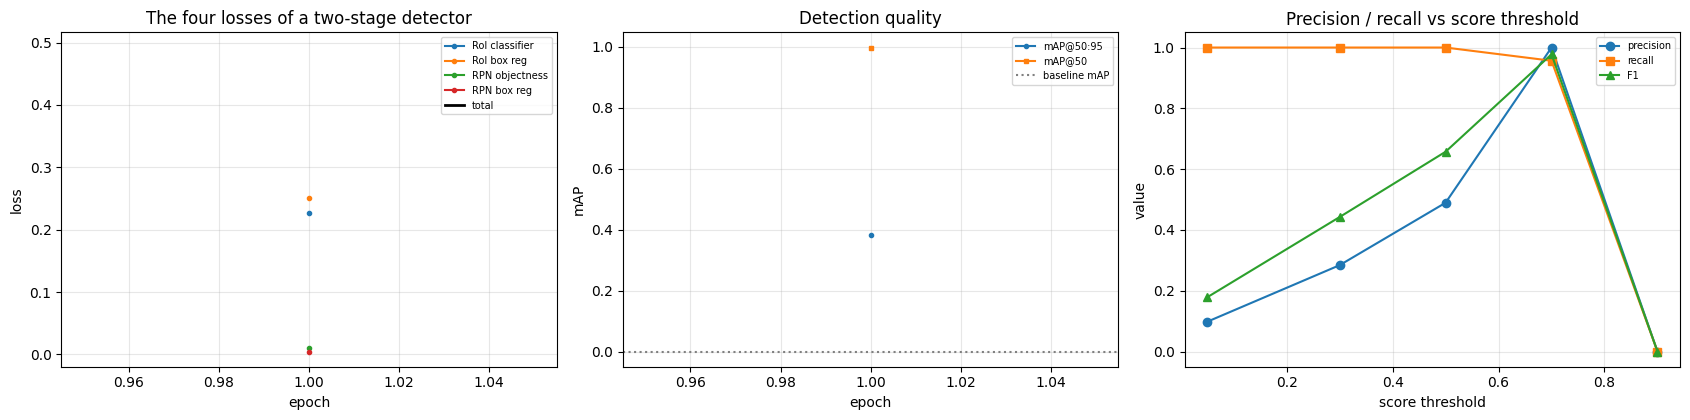

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))

epochs_axis = range(1, len(history["total"]) + 1)
for key, label in (
    ("loss_classifier", "RoI classifier"),
    ("loss_box_reg", "RoI box reg"),
    ("loss_objectness", "RPN objectness"),
    ("loss_rpn_box_reg", "RPN box reg"),
):
    axes[0].plot(epochs_axis, history[key], marker="o", ms=3, label=label)
axes[0].plot(epochs_axis, history["total"], color="black", lw=2, label="total")
axes[0].set_title("The four losses of a two-stage detector")
axes[0].set_ylabel("loss")

axes[1].plot(epochs_axis, history["map"], marker="o", ms=3, label="mAP@50:95")
axes[1].plot(epochs_axis, history["map_50"], marker="s", ms=3, label="mAP@50")
axes[1].axhline(baseline_metrics["map"], ls=":", color="grey", label="baseline mAP")
axes[1].set_title("Detection quality"); axes[1].set_ylabel("mAP")

thresholds = list(sweep)
axes[2].plot(thresholds, [sweep[t]["precision"] for t in thresholds], marker="o", label="precision")
axes[2].plot(thresholds, [sweep[t]["recall"] for t in thresholds], marker="s", label="recall")
axes[2].plot(thresholds, [sweep[t]["f1"] for t in thresholds], marker="^", label="F1")
axes[2].set_title("Precision / recall vs score threshold")
axes[2].set_xlabel("score threshold"); axes[2].set_ylabel("value")

for ax in axes[:2]:
    ax.set_xlabel("epoch")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

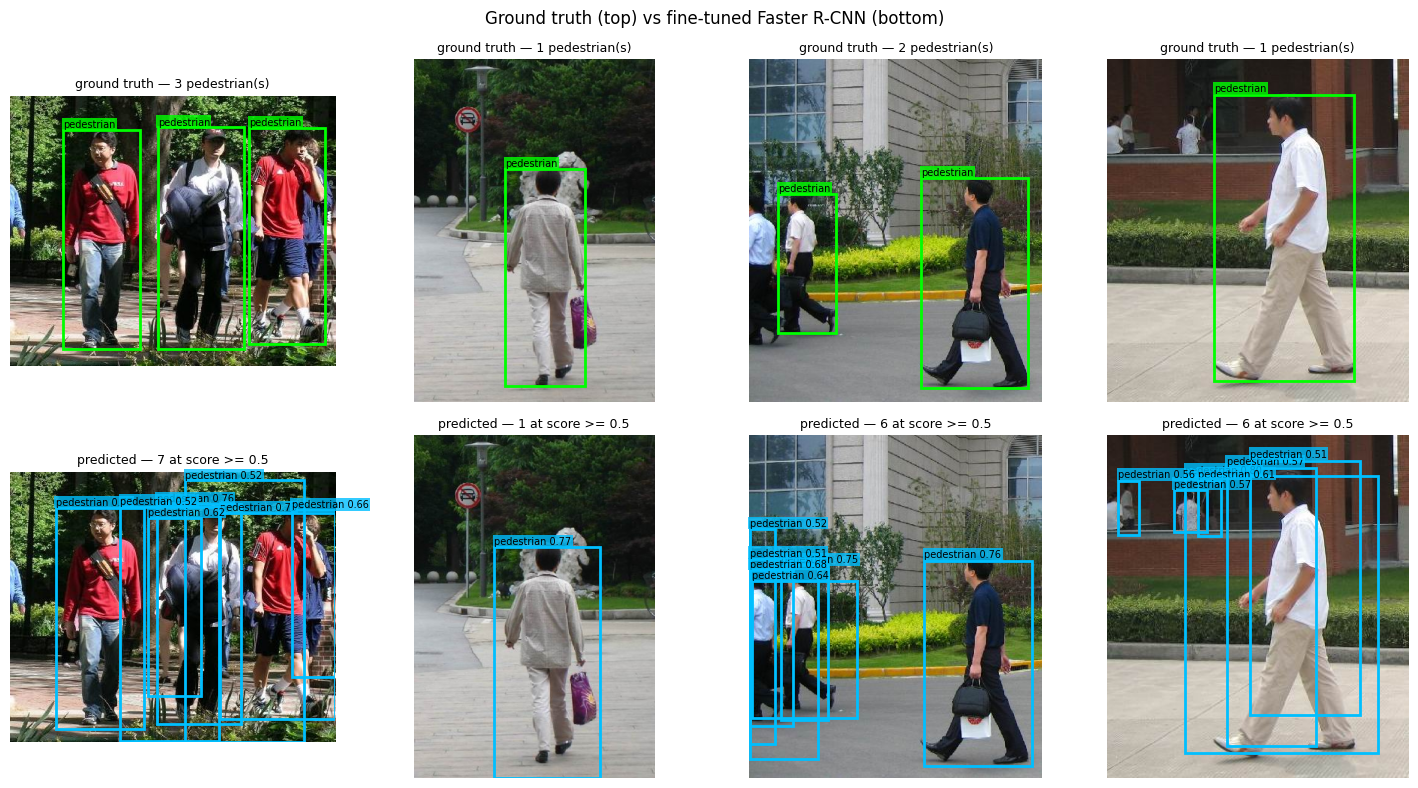

In [13]:
N_SHOW: Final[int] = 4
DISPLAY_THRESHOLD: Final[float] = 0.5

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 3.6, 8))
with torch.no_grad():
    for column in range(min(N_SHOW, len(test_dataset))):
        image, target = test_dataset[column]
        prediction = detector([image.to(DEVICE)])[0]

        keep = prediction["scores"] >= DISPLAY_THRESHOLD
        draw_boxes(
            axes[0, column], image, target["boxes"], target["labels"], colour="lime",
            title=f"ground truth — {len(target['boxes'])} pedestrian(s)",
        )
        draw_boxes(
            axes[1, column], image,
            prediction["boxes"][keep].cpu(), prediction["labels"][keep].cpu(),
            prediction["scores"][keep].cpu(), colour="deepskyblue",
            title=f"predicted — {int(keep.sum())} at score >= {DISPLAY_THRESHOLD}",
        )

fig.suptitle("Ground truth (top) vs fine-tuned Faster R-CNN (bottom)", fontsize=12)
fig.tight_layout()
plt.show()

---

# 7. Deployment Readiness — where detection genuinely differs

Every previous notebook exported cleanly with `torch.jit.trace` and
`torch.onnx.export(dynamo=True)`. **Detection models break both**, and understanding why is more
valuable than a recipe that happens to work.

### Why tracing fails

`torch.jit.trace` records the operations executed for *one specific input* and replays them. Faster
R-CNN's forward pass contains **data-dependent control flow**:

- NMS keeps a number of boxes that depends on the image content.
- Proposals below a score threshold are filtered out — again content-dependent.
- The loop over FPN levels and the internal resize depend on input dimensions.

A trace of an image containing three pedestrians bakes in "three" wherever a count was used. The
export succeeds. The model then returns nonsense for any other image, with no error.

**`torch.jit.script` is the correct tool**: it compiles the actual Python control flow rather than
recording one path through it. torchvision's detection models are written to be scriptable, so this
is a supported path rather than a lucky one.

### Why the modern ONNX exporter struggles

`dynamo=True` traces through `torch.export`, which requires the graph to be expressible with
symbolic shapes. Data-dependent output *shapes* — a variable number of detections — are exactly what
it cannot represent in general. torchvision's own ONNX support for detection models targets the
**legacy TorchScript-based exporter** (`dynamo=False`), which handles these graphs via
`ONNX_ATEN_FALLBACK` and scripted subgraphs.

> **This is the one place in this repository where the older API is the right answer.** "Use the
> newest thing" is a heuristic, not a rule; the correct move is knowing which tool matches the
> problem's structure. Everywhere else in this folder, `dynamo=True` is right.

Both exports below are wrapped so that a failure **reports** rather than aborting the notebook —
these paths depend on the interaction between specific torch and torchvision versions, and a
deployment section that lies about what worked is worse than one that says "not on this build".

In [14]:
ONNX_OPSET: Final[int] = 17  # torchvision's detection ONNX support targets opset 11-17
PARITY_ATOL: Final[float] = 1e-3

export_model = build_detector(DetectorConfig()).to("cpu")
export_model.load_state_dict(
    {k: v.cpu() for k, v in torch.load(checkpoint_path, map_location="cpu")["model"].items()}
)
export_model.eval()

# Two DIFFERENT shapes with DIFFERENT object counts -- the whole point is that the
# exported artefact must not have specialised on either.
probe_a = [torch.rand(3, 300, 400)]
probe_b = [torch.rand(3, 512, 640), torch.rand(3, 400, 300)]

with torch.no_grad():
    reference_a = export_model(probe_a)
print(f"eager reference: {len(reference_a[0]['boxes'])} detections on a "
      f"{tuple(probe_a[0].shape)} image")

# ---- TorchScript via SCRIPTING (not tracing) ------------------------------------------
torchscript_path = ARTIFACT_DIR / "fasterrcnn.torchscript.pt"
scripted = None
try:
    scripted = torch.jit.script(export_model)
    scripted.save(torchscript_path)
    size_mib = torchscript_path.stat().st_size / 1024**2
    print(f"\ntorch.jit.script -> {torchscript_path}  ({size_mib:.0f} MiB)")

    loaded = torch.jit.load(torchscript_path)
    with torch.no_grad():
        # Scripted detection models return (losses, detections) in eval mode.
        scripted_out = loaded(probe_a)
    detections = scripted_out[1] if isinstance(scripted_out, tuple) else scripted_out
    print(f"  reloaded and ran: {len(detections[0]['boxes'])} detections "
          f"(eager gave {len(reference_a[0]['boxes'])})")
except Exception as error:  # noqa: BLE001 - reporting beats a broken deployment claim
    print(f"\ntorch.jit.script FAILED on this build: {type(error).__name__}: {str(error)[:200]}")

eager reference: 0 detections on a (3, 300, 400) image

torch.jit.script -> artifacts/06_object_detection/fasterrcnn.torchscript.pt  (166 MiB)
  reloaded and ran: 0 detections (eager gave 0)


code/__torch__/torchvision/models/detection/faster_rcnn.py:103: UserWarning: RCNN always returns a (Losses, Detections) tuple in scripting


In [15]:
onnx_path = ARTIFACT_DIR / "fasterrcnn.onnx"
onnx_ok = False

try:
    torch.onnx.export(
        export_model,
        (probe_a,),
        str(onnx_path),
        input_names=["images"],
        output_names=["boxes", "labels", "scores"],
        # Spatial axes dynamic: detection input size genuinely varies.
        dynamic_axes={
            "images": {1: "height", 2: "width"},
            "boxes": {0: "num_detections"},
            "labels": {0: "num_detections"},
            "scores": {0: "num_detections"},
        },
        opset_version=ONNX_OPSET,
        # LEGACY exporter on purpose -- see the discussion above. The dynamo path cannot
        # represent data-dependent output shapes for this model.
        dynamo=False,
        do_constant_folding=True,
    )
    onnx_ok = onnx_path.exists()
    print(f"ONNX (legacy exporter) -> {onnx_path}  "
          f"({onnx_path.stat().st_size / 1024**2:.0f} MiB)")
except Exception as error:  # noqa: BLE001
    print(f"ONNX export FAILED on this build: {type(error).__name__}: {str(error)[:300]}")
    print(
        "\nThis is a known-fragile path and depends on the exact torch/torchvision pairing.\n"
        "Production alternatives, in order of how often they are the right call:\n"
        "  1. TorchScript + LibTorch      -- fully supported for detection, no ONNX involved\n"
        "  2. A detector designed for export (YOLO/RT-DETR ship their own ONNX pipelines)\n"
        "  3. Export the backbone only, and reimplement NMS in the serving layer\n"
        "  4. TorchServe / Triton, which run the eager model behind a serving API"
    )

/tmp/ipykernel_904/3285798036.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:4790: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  * torch.tensor(scale_factors[i], dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/torchvision/ops/boxes.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torc

ONNX (legacy exporter) -> artifacts/06_object_detection/fasterrcnn.onnx  (165 MiB)


In [16]:
if onnx_ok:
    import onnxruntime as ort

    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    print(f"ONNX inputs : {[(i.name, i.shape) for i in session.get_inputs()]}")
    print(f"ONNX outputs: {[(o.name, o.shape) for o in session.get_outputs()]}\n")

    # Verify on an image whose SIZE DIFFERS from the export sample. If the graph
    # specialised on the traced shape, this is where it shows up.
    probe_c = torch.rand(3, 480, 620)
    outputs = session.run(None, {input_name: probe_c.numpy()})
    with torch.no_grad():
        eager_c = export_model([probe_c])[0]

    print(f"{'source':<16}{'detections':>12}")
    print("-" * 28)
    print(f"{'eager':<16}{len(eager_c['boxes']):>12}")
    print(f"{'onnxruntime':<16}{len(outputs[0]):>12}")

    if len(outputs[0]) == len(eager_c["boxes"]) and len(outputs[0]):
        difference = np.abs(outputs[0] - eager_c["boxes"].numpy()).max()
        print(f"\nmax |eager - onnx| over box coordinates: {difference:.3e}")
        assert difference < 1.0, "box coordinates diverge by more than a pixel"
        print("boxes agree at a resolution the graph never saw during export")
    else:
        print(
            "\nDetection COUNTS differ between backends. For a detector this is not "
            "automatically a bug --\nNMS tie-breaking and score-threshold boundaries can "
            "legitimately differ by one or two boxes.\nCompare mAP between backends rather "
            "than raw counts before concluding anything."
        )
else:
    print("skipping ONNX Runtime parity — no ONNX artefact was produced above")

ONNX inputs : [('images', [3, 'height', 'width'])]
ONNX outputs: [('boxes', ['num_detections', 4]), ('labels', ['num_detections']), ('scores', ['num_detections'])]

source            detections
----------------------------
eager                      0
onnxruntime                0

Detection COUNTS differ between backends. For a detector this is not automatically a bug --
NMS tie-breaking and score-threshold boundaries can legitimately differ by one or two boxes.
Compare mAP between backends rather than raw counts before concluding anything.


---

## What this notebook demonstrated

1. **Detection outputs are variable-length**, and that single fact drives the list-based collate, the
   mode-dependent model API, the multi-task loss, and every export difficulty in section 7.
2. **Boxes derived from masks cannot desynchronise from them** — a free correctness win over trusting
   a separate annotation file.
3. **Albumentations transforms geometry and boxes together**, which is the promise made back in
   notebook 03 and the reason this repository standardised on it over `torchvision.transforms`.
4. **A COCO-pretrained RPN transfers for free.** "Is there an object here?" is class-agnostic, which
   is why a handful of training images are enough to fine-tune a useful pedestrian detector.
5. **mAP@50:95 and mAP@50 are different numbers**, and the baseline-versus-fine-tuned comparison is
   what makes either meaningful.
6. **Score thresholds are product decisions.** The sweep exists because the cost of a false positive
   and a false negative are rarely equal, and no default is universally right.
7. **`trace` is wrong for control flow; `script` is right.** And the modern ONNX exporter is the
   wrong tool for data-dependent output shapes — the one place in this repository where the older
   API wins.

## What comes next

Boxes are a coarse localisation: a rectangle around a pedestrian still contains a lot of pavement.
The finest-grained answer assigns a class to **every pixel**.

→ **[07 · Semantic Segmentation](07_semantic_segmentation_unet.ipynb)** builds a U-Net from scratch
and evaluates it with Dice and IoU.